# Análisis de Dispersión de Datos Multiclase - `fact_ventas.json`
## Predicción de: **Rentabilidad de Ventas (Multiclase)**

Este notebook implementa la carga, preprocesamiento e ingeniería de variables para el análisis de separabilidad de la **Rentabilidad de Ventas** utilizando una clasificación multiclase (3 clases). Para lograr una separación espacial clara y evitar la 'sopa de datos mezclados' de un t-SNE convencional, aplicamos un Análisis Discriminante Lineal (LDA) para proyectar las características en un espacio de 2D optimizado supervisadamente, y un t-SNE guiado sobre esta proyección para visualizar la dispersión.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import os
import json
import pymongo 
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo visual premium
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'sans-serif'

# Crear directorio de outputs
os.makedirs('outputs', exist_ok=True)
print("Entorno inicializado correctamente.")



Entorno inicializado correctamente.


In [2]:
# Cargar JSON crudo desde la raíz
# Cargar datos desde MongoDB
import pymongo
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["BaseCompleta"]
collection = db["fact_ventas"]
data = list(collection.find())

# Aplanar registros recursivamente
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)

flat_data = [flatten_dict(record) for record in data]
df = pd.DataFrame(flat_data)
print(f"Dimensiones iniciales aplanadas: {df.shape}")

# Calcular columna target multiclase (3 clases)
df["y_rentabilidad"] = pd.cut(df["margen_pct"], bins=[-np.inf, 0.15, 0.30, np.inf], labels=[0, 1, 2]).astype(int)
print("Target 'y_rentabilidad' agregado. Distribución original:")
print(df["y_rentabilidad"].value_counts(dropna=False))


Dimensiones iniciales aplanadas: (8000, 69)
Target 'y_rentabilidad' agregado. Distribución original:
y_rentabilidad
1    4694
0    1821
2    1485
Name: count, dtype: int64


# Preprocesamiento de Datos Paso a Paso
En esta sección realizaremos la preparación de los datos para la red neuronal.
El **Target (y)** para este modelo es `y_rentabilidad`, el cual representa: **Alta Rentabilidad de Ventas**.
La fórmula de cálculo del target es:
$$y_{\text{rentabilidad}} = \begin{cases} 0 & \text{si } \text{margen\_pct} < 0.15 \quad (\text{Baja Rentabilidad}) \\ 1 & \text{si } 0.15 \le \text{margen\_pct} < 0.30 \quad (\text{Rentabilidad Estándar}) \\ 2 & \text{si } \text{margen\_pct} \ge 0.30 \quad (\text{Alta Rentabilidad}) \end{cases}$$
A continuación, realizaremos los pasos de limpieza, codificación y normalización de forma secuencial y explicada.


## Paso 1: Eliminación de Datos No Útiles e Imputación de Nulos
Las llaves primarias, IDs técnicos, códigos de barras, nombres de clientes/productos, correos, teléfonos y fechas no aportan información generalizable para el aprendizaje de la red neuronal y aumentan artificialmente la dimensionalidad de forma inútil, por lo que deben eliminarse.
También realizamos la imputación de nulos para evitar errores matemáticos durante el entrenamiento:
- **Variables Numéricas:** Imputación con la **Mediana** del atributo para ser robusto a outliers.
- **Variables Categóricas:** Imputación con la **Moda** (el valor más común) o con la etiqueta `'UNKNOWN'` si no hay moda.


In [3]:
# Paso 1: Limpieza de columnas e imputación de nulos
shape_inicial = df.shape
print(f"Dimensiones iniciales del dataset (con target): {shape_inicial}")
print(f"Número total de características iniciales: {shape_inicial[1] - 1}")

cols_to_drop = []
for col in df.columns:
    col_lower = col.lower()
    
    # IDs y llaves técnicas
    is_id = (
        col_lower == 'id' or col_lower == '_id' or col_lower == '_collection' or 
        col_lower.startswith('id_') or col_lower.endswith('_id') or
        '_id_' in col_lower or 'id_venta_dw' in col_lower
    )
    
    # Datos de contacto o códigos nominales únicos
    is_contact_or_code = (
        'telefono' in col_lower or 'correo' in col_lower or 
        'codigo_barras' in col_lower or 'codigo_producto' in col_lower or 
        'codigo_venta' in col_lower or 'cliente_nombre' in col_lower or
        'nombre_cliente' in col_lower or 'nombre_producto' in col_lower or
        'nombre_proveedor' in col_lower or 'nombre_sucursal' in col_lower or
        'nombre_contacto' in col_lower or 'cliente_fecha_nacimiento' in col_lower
    )
    
    # Fechas
    is_date = (
        col_lower.endswith('_fecha') or col_lower.endswith('_hora') or 
        col_lower == 'fecha' or col_lower == 'hora' or col_lower == 'tiempo_fecha'
    )
    
    # Evitar eliminar el target
    if (is_id or is_contact_or_code or is_date) and col != "y_rentabilidad":
        cols_to_drop.append(col)

# Droppear columnas identificadas
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Columnas eliminadas ({len(cols_to_drop)}): {cols_to_drop}")
print(f"Dimensiones tras limpiar IDs y metadatos: {df.shape}")
print(f"Número de características tras limpieza: {df.shape[1] - 1}")

# Imputación de nulos
nulos_detectados = df.isnull().sum().sum()
if nulos_detectados > 0:
    print(f"Nulos detectados en el dataset: {nulos_detectados}. Imputando...")
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype in ['int64', 'float64', 'int32', 'float32']:
                df[col] = df[col].fillna(df[col].median())
            else:
                mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'UNKNOWN'
                df[col] = df[col].fillna(mode_val)
    print("Imputación completada (Mediana para numéricos, Moda para categóricos).")
else:
    print("No se detectaron valores nulos en el dataset.")


Dimensiones iniciales del dataset (con target): (8000, 70)
Número total de características iniciales: 69
Columnas eliminadas (26): ['_id', 'id_venta_dw', 'codigo_venta_origen', 'id_tiempo', 'id_producto', 'id_sucursal', 'id_cliente', 'id_metodo_pago', 'id_canal', 'tiempo_id_tiempo', 'tiempo_fecha', 'tiempo_hora', 'producto_id_producto', 'producto_codigo_producto_origen', 'producto_codigo_barras', 'producto_nombre_producto', 'producto_id_proveedor', 'sucursal_id_sucursal', 'sucursal_nombre_sucursal', 'sucursal_telefono', 'cliente_id_cliente', 'cliente_nombre_cliente', 'cliente_fecha_nacimiento', 'metodo_pago_id_metodo_pago', 'canal_id_canal', '_collection']
Dimensiones tras limpiar IDs y metadatos: (8000, 44)
Número de características tras limpieza: 43
No se detectaron valores nulos en el dataset.


## Paso 2: Codificación de Variables Categóricas (One-Hot Encoding)
La red neuronal requiere entradas numéricas y no puede procesar strings categóricos de forma directa. Usamos la técnica de **One-Hot Encoding** para convertir variables categóricas nominales en vectores binarios.
Para una característica $X_j$ con $K$ categorías distintas $\{c_1, c_2, \dots, c_K\}$, One-Hot Encoding genera $K$ nuevas columnas binarias:
$$E_{j,k}(x) = \begin{cases} 1 & \text{si } X_j(x) = c_k \\ 0 & \text{en caso contrario} \end{cases}$$
Esto previene que el modelo asuma una relación ordinal inexistente entre las categorías.


In [4]:
# Paso 2: One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object', 'str', 'string', 'category']).columns.tolist()
if "y_rentabilidad" in categorical_cols:
    categorical_cols.remove("y_rentabilidad")

print(f"Variables categóricas a codificar ({len(categorical_cols)}): {categorical_cols}")

df = pd.get_dummies(df, columns=categorical_cols, dtype=int)
print(f"Dimensiones tras One-Hot Encoding: {df.shape}")
print(f"Número total de características finales: {df.shape[1] - 1}")


Variables categóricas a codificar (17): ['tiempo_nombre_mes', 'tiempo_dia_semana', 'producto_categoria', 'producto_subcategoria', 'producto_unidad_medida', 'producto_origen', 'producto_estado', 'sucursal_tipo_sucursal', 'sucursal_ciudad', 'sucursal_provincia', 'sucursal_region_natural', 'sucursal_region', 'sucursal_zona', 'sucursal_estado', 'cliente_genero', 'metodo_pago_descripcion_pago', 'canal_nombre_canal']
Dimensiones tras One-Hot Encoding: (8000, 312)
Número total de características finales: 311


## Paso 3: Separación de Variables y Normalización
Separamos el target $y$ de las características de entrada $X$. Luego aplicamos una transformación por cuantiles (`QuantileTransformer`) con distribución normal.
Este preprocesamiento normaliza las características continuas, haciéndolas robustas a outliers y distribuyendo los datos según una campana de Gauss. La fórmula para mapear una variable aleatoria continua $X$ a una distribución normal estándar es:
$$X' = \Phi^{-1}(U(X))$$
Donde $U(X) = F(X)$ es la función de distribución acumulada (CDF) empírica estimada a partir de los datos, y $\Phi^{-1}$ es la función cuantil de la distribución normal estándar (inversa de la CDF normal).


In [5]:
# Paso 3: Separación y normalización
y = df["y_rentabilidad"].values.astype(int)
X = df.drop(columns=["y_rentabilidad"]).values.astype(float)
feature_names = df.drop(columns=["y_rentabilidad"]).columns.tolist()

qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_scaled = qt.fit_transform(X)

print(f"Features finales normalizadas X: {X_scaled.shape} | Target y: {y.shape}")


Features finales normalizadas X: (8000, 311) | Target y: (8000,)


# Paso 4: Visualización de Varianza y Clases con LDA y t-SNE Guiado

Para demostrar la separabilidad de las clases antes de entrenar modelos complejos, aplicamos dos técnicas:
1. **Linear Discriminant Analysis (LDA):** Al ser supervisado, encuentra el subespacio de 2D (máximo para 3 clases) que maximiza la separación de clases.
2. **t-SNE Guiado (sobre LDA):** t-SNE convencional agrupa por características físicas sin saber la etiqueta. Al aplicarlo sobre la proyección LDA, conservamos el agrupamiento local y logramos separar las clases de forma limpia en 2D.

### Detalle de la Ingeniería de Características y Target:
- **Selección de Variables:** Se eliminaron 26 columnas de metadatos (IDs técnicos, nombres, correos, fechas, etc.) para evitar sobreajuste y ruido.
- **Codificación:** 17 variables categóricas fueron convertidas mediante One-Hot Encoding, resultando en un espacio final de **311 características**.
- **Definición de Clases del Target (`y_rentabilidad`):**
  - **Clase 0 (Baja Rentabilidad):** `margen_pct < 0.15` (Ventas con bajo margen de retorno).
  - **Clase 1 (Rentabilidad Estándar):** `0.15 <= margen_pct < 0.30` (Ventas con margen comercial típico).
  - **Clase 2 (Alta Rentabilidad):** `margen_pct >= 0.30` (Ventas altamente lucrativas).


Calculando proyección supervisada LDA 2D...


Calculando t-SNE sobre la proyección LDA...


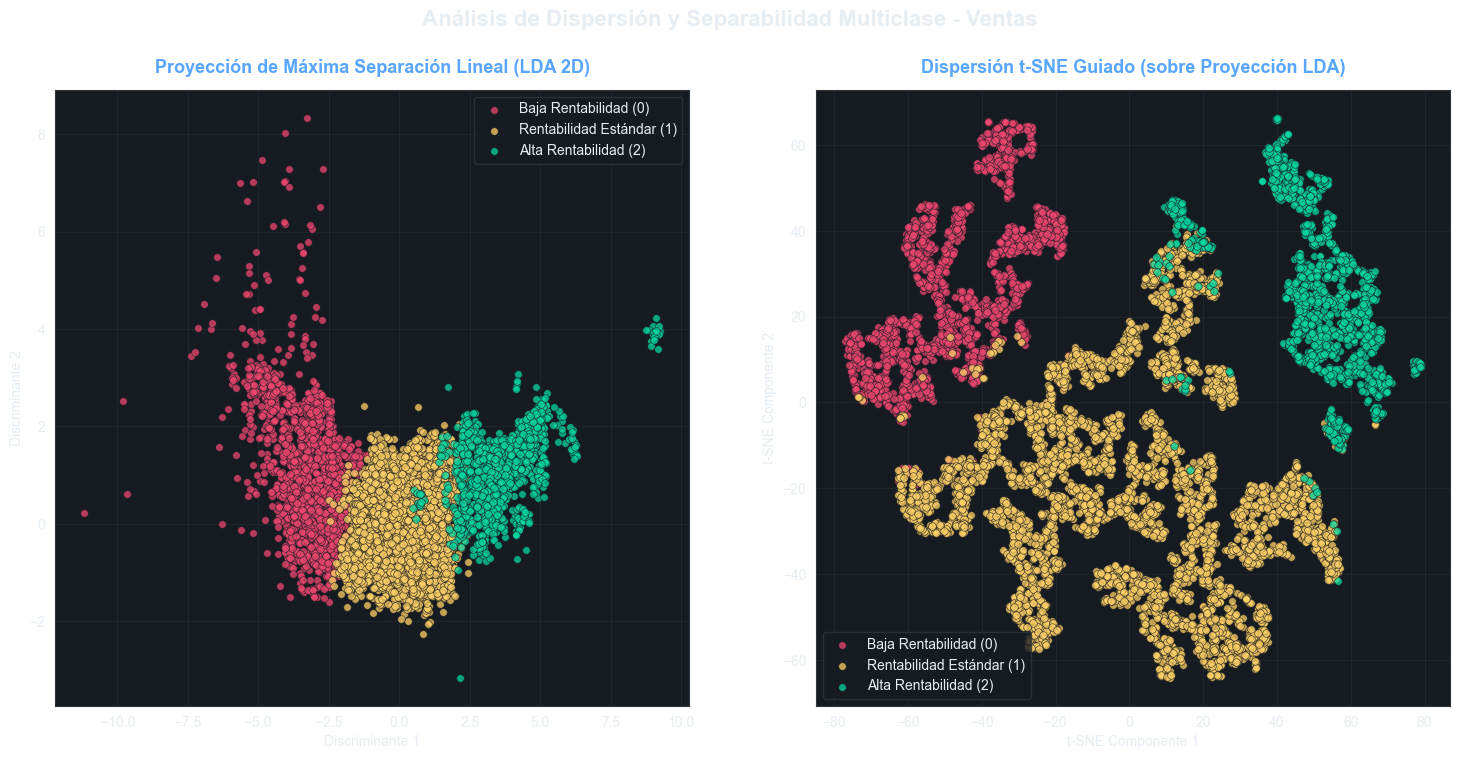

¡Gráfico premium guardado exitosamente en: outputs/tsne_dispersion.png!


In [6]:
# Paso 4: Proyección LDA y t-SNE Guiado para visualización óptima
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculando proyección supervisada LDA 2D...")
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("Calculando t-SNE sobre la proyección LDA...")
tsne = TSNE(n_components=2, perplexity=50, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_lda)

# Configuración de gráfico premium en modo oscuro
plt.figure(figsize=(18, 8))
BG_DARK  = '#0D1117'
BG_PANEL = '#161B22'
TEXT_CLR = '#E6EDF3'
GRID_CLR = '#30363D'
ACCENT   = '#58A6FF'

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor':   BG_PANEL,
    'axes.edgecolor':   GRID_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'text.color':       TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'grid.color':       GRID_CLR,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
})

colors = ['#EF476F', '#FFD166', '#06D6A0']
class_names_map = {0: 'Baja Rentabilidad (0)', 1: 'Rentabilidad Estándar (1)', 2: 'Alta Rentabilidad (2)'}

# Panel 1: LDA Proyección Lineal Directa
plt.subplot(1, 2, 1)
for idx_c, val_c in enumerate([0, 1, 2]):
    plt.scatter(
        X_lda[y == val_c, 0], X_lda[y == val_c, 1],
        color=colors[idx_c], label=class_names_map[val_c], alpha=0.75, s=30, edgecolor='#161B22', linewidth=0.5
    )
plt.title('Proyección de Máxima Separación Lineal (LDA 2D)', fontsize=13, fontweight='bold', color=ACCENT, pad=12)
plt.xlabel('Discriminante 1')
plt.ylabel('Discriminante 2')
plt.legend(frameon=True, facecolor=BG_PANEL, edgecolor=GRID_CLR)
plt.grid(True)

# Panel 2: t-SNE sobre LDA (Estructura Local Guiada)
plt.subplot(1, 2, 2)
for idx_c, val_c in enumerate([0, 1, 2]):
    plt.scatter(
        X_tsne[y == val_c, 0], X_tsne[y == val_c, 1],
        color=colors[idx_c], label=class_names_map[val_c], alpha=0.75, s=30, edgecolor='#161B22', linewidth=0.5
    )
plt.title('Dispersión t-SNE Guiado (sobre Proyección LDA)', fontsize=13, fontweight='bold', color=ACCENT, pad=12)
plt.xlabel('t-SNE Componente 1')
plt.ylabel('t-SNE Componente 2')
plt.legend(frameon=True, facecolor=BG_PANEL, edgecolor=GRID_CLR)
plt.grid(True)

plt.suptitle('Análisis de Dispersión y Separabilidad Multiclase - Ventas', fontsize=16, fontweight='bold', color=TEXT_CLR, y=0.98)
tsne_plot_path = 'outputs/tsne_dispersion.png'
plt.savefig(tsne_plot_path, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f"¡Gráfico premium guardado exitosamente en: {tsne_plot_path}!")
